# **Etape 1 : EDA**
**Chargement des données et examination de la structure**

In [86]:
import pandas as pd

df = pd.read_parquet("yellow_tripdata_2025-01.parquet")
df = df.sample(100_000, random_state=5).reset_index(drop=True)
print(df.shape)
print(df.dtypes)
df.head()

(100000, 20)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-01-11 11:43:46,2025-01-11 11:58:27,1.0,2.85,1.0,N,68,143,1,16.30,0.00,0.5,5.26,0.0,1.0,26.31,2.5,0.0,0.75
1,2,2025-01-29 19:15:17,2025-01-29 19:20:25,1.0,1.11,1.0,N,237,237,1,7.90,2.50,0.5,2.00,0.0,1.0,16.40,2.5,0.0,0.00
2,2,2025-01-11 23:47:14,2025-01-12 00:07:52,NaN,3.86,NaN,None,249,50,0,21.86,0.00,0.5,0.00,0.0,1.0,26.61,NaN,NaN,0.75
3,1,2025-01-22 08:57:53,2025-01-22 09:03:19,1.0,0.60,1.0,N,161,163,1,7.20,3.25,0.5,2.35,0.0,1.0,14.30,2.5,0.0,0.75
4,2,2025-01-18 12:26:34,2025-01-18 12:42:43,1.0,2.21,1.0,N,144,90,1,15.60,0.00,0.5,4.07,0.0,1.0,24.42,2.5,0.0,0.75


**Préparation au nettoyage de données : créations de variables et identification de valeurs aberrantes**

In [87]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Afin de préparer le nettoyage des données, j'ajoute en avance cette variable de l'étape 2. Je pourrais m'en servir lors du filtrage
df["duree_course"] = (df["tpep_dropoff_datetime"]-df["tpep_pickup_datetime"]).dt.total_seconds()/60

In [88]:
print(f"Durées négatives : {(df['duree_course']<0).sum()}")
print(f"Durées >2h30: {(df['duree_course']>150).sum()}")

Durées négatives : 4
Durées >2h30: 40


In [89]:
# Permet d'identifier basiquement certaines valeurs aberrantes (min passenger count = 0 ?)
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duree_course
count,100000.000000,100000,100000,84412.000000,100000.000000,84412.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,84412.000000,84412.000000,100000.000000,100000.000000
mean,1.784660,2025-01-17 12:27:53.179900,2025-01-17 12:42:51.754020,1.293608,5.640609,2.477811,165.340750,164.017570,1.034730,16.777663,1.317275,0.478195,2.958265,0.443847,0.954414,25.298049,2.228534,0.123913,0.484013,14.976235
min,1.000000,2025-01-01 00:01:20,2025-01-01 00:10:01,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-400.000000,-7.500000,-0.500000,-0.900000,-40.000000,-1.000000,-401.000000,-2.500000,-1.750000,-0.750000,-17.200000
25%,2.000000,2025-01-10 09:40:28.750000,2025-01-10 09:54:48.750000,1.000000,0.980000,1.000000,132.000000,113.000000,1.000000,8.600000,0.000000,0.500000,0.000000,0.000000,1.000000,15.180000,2.500000,0.000000,0.000000,7.300000
50%,2.000000,2025-01-17 16:46:09.500000,2025-01-17 17:03:33,1.000000,1.670000,1.000000,162.000000,162.000000,1.000000,12.100000,0.000000,0.500000,2.450000,0.000000,1.000000,19.950000,2.500000,0.000000,0.750000,11.683333
75%,2.000000,2025-01-24 21:11:03.750000,2025-01-24 21:23:24,1.000000,3.100000,1.000000,234.000000,234.000000,1.000000,19.500000,2.500000,0.500000,3.930000,0.000000,1.000000,27.750000,2.500000,0.000000,0.750000,18.337500
max,7.000000,2025-01-31 23:59:30,2025-02-01 00:33:57,6.000000,189687.430000,99.000000,265.000000,265.000000,4.000000,544.100000,12.500000,4.000000,99.990000,46.000000,1.000000,548.100000,2.500000,1.750000,0.750000,1438.633333
std,0.424936,NaN,NaN,0.746755,633.331930,11.624035,64.431557,69.482129,0.698734,17.722091,1.865392,0.137467,3.724405,1.971992,0.279664,22.036736,0.899631,0.474501,0.361836,24.896405


In [90]:
# Repérer les valeurs nulles
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,15588
trip_distance,0
RatecodeID,15588
store_and_fwd_flag,15588
PULocationID,0
DOLocationID,0
payment_type,0


**Nettoyage des données : mise en place d'un filtre**

In [91]:
# Création d'un filtre pour nettoyer le dataset. Ce filtre a pour but de fonctionner sur tout sample, pas que le mien (passenger_count max de cet échantillon est 6 mais je met le filtre à 12 par exemple)
filtre=(
    (df["trip_distance"] > 0)  # tout trajet doit avoir une distance
    & (df["trip_distance"] < 50) # un trajet de taxi aussi long n'est pas normal, même pour les plus fortunés
    & (df["passenger_count"] > 0) # une course de taxi doit avoir un client
    & (df["passenger_count"] <= 11) # les fourgons ont maximum 12 places à ma connaissance, donc 11 clients
    & (df["duree_course"] > 0) # un trajet a une durée
    & (df["duree_course"] < 150) # un trajet de maximum 50km ne prend pas plus de 2h30 même avec bouchons
    & (df["fare_amount"] > 0) # un taxi n'est pas bénévole
    & (df["fare_amount"] < 300) # au vu des tarifs des taxis new yorkais et de mes filtres de distance / durée, on ne devrait jamais atteindre ce tarif
)

# Permet d'estimer l'efficacité des filtres et les perfectionner si necessaire
print(f"Lignes supprimées : {(~filtre).sum()}")
print(f"Lignes conservées : {filtre.sum()}")

# Appliquer le filtre
df = df[filtre].copy()

Lignes supprimées : 19076
Lignes conservées : 80924


In [92]:
# Verification basique que le describe n'est plus le même
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duree_course
count,80924.000000,80924,80924,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000,80924.000000
mean,1.775790,2025-01-17 04:15:35.522959,2025-01-17 04:30:09.127811,1.301802,3.159814,2.432196,167.221924,166.057869,1.173397,17.853320,1.597535,0.495978,3.497200,0.522206,0.987099,27.279387,2.328697,0.133579,0.488106,14.560081
min,1.000000,2025-01-01 00:01:20,2025-01-01 00:10:01,1.000000,0.010000,1.000000,3.000000,1.000000,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,2.190000,0.000000,0.000000,0.000000,0.033333
25%,2.000000,2025-01-09 17:05:27.750000,2025-01-09 17:22:07.250000,1.000000,0.990000,1.000000,132.000000,116.000000,1.000000,8.600000,0.000000,0.500000,1.330000,0.000000,1.000000,15.950000,2.500000,0.000000,0.000000,7.100000
50%,2.000000,2025-01-16 22:51:29.500000,2025-01-16 23:02:12,1.000000,1.620000,1.000000,162.000000,162.000000,1.000000,12.100000,1.000000,0.500000,2.890000,0.000000,1.000000,20.300000,2.500000,0.000000,0.750000,11.333333
75%,2.000000,2025-01-24 19:21:02.500000,2025-01-24 19:32:33.250000,1.000000,3.000000,1.000000,234.000000,234.000000,1.000000,19.100000,2.500000,0.500000,4.250000,0.000000,1.000000,28.560000,2.500000,0.000000,0.750000,18.133333
max,2.000000,2025-01-31 23:59:06,2025-02-01 00:29:58,6.000000,48.580000,99.000000,265.000000,265.000000,4.000000,296.300000,12.500000,0.500000,99.990000,46.000000,1.000000,348.960000,2.500000,1.750000,0.750000,146.933333
std,0.417064,NaN,NaN,0.737178,4.222396,11.502912,62.910536,68.808650,0.472243,16.367202,1.897980,0.044665,3.731861,2.044151,0.112848,20.817527,0.631599,0.464675,0.357538,11.552739


In [105]:
# Vérification qu'il n'y a plus de valeurs nulles
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


**Visualisations exploratoires du dataset**

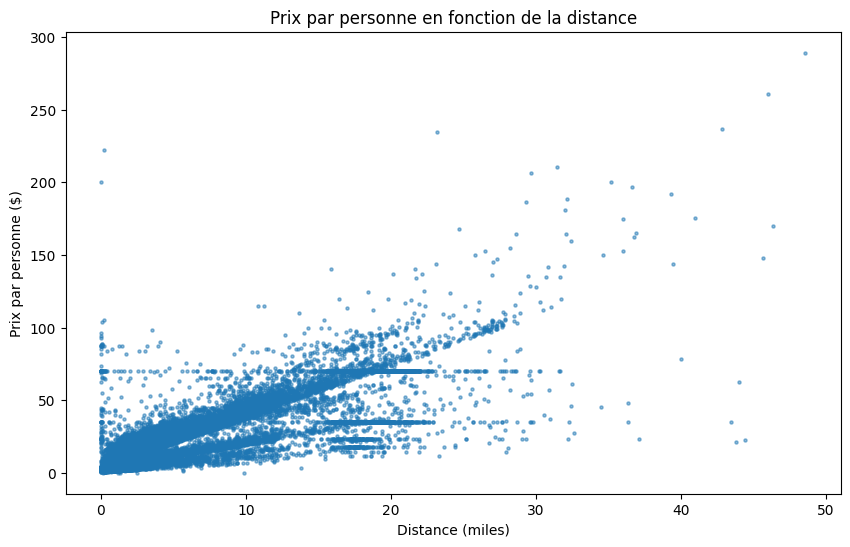

In [93]:
import matplotlib.pyplot as plt

# Prix par personne, je me suis rendu compte dans le projet avec Olivier Pitton que ce dataset présentait des trajets à 80 000 $ donc je voulais modéliser le graphe avant / après filtre et je confirme qu'il change
df["prix_par_personne"] = df["fare_amount"] / df["passenger_count"]

plt.figure(figsize=(10, 6))
plt.scatter(df["trip_distance"], df["prix_par_personne"], alpha=0.5, s=5)

plt.xlabel("Distance (miles)")
plt.ylabel("Prix par personne ($)")
plt.title("Prix par personne en fonction de la distance")
plt.show()

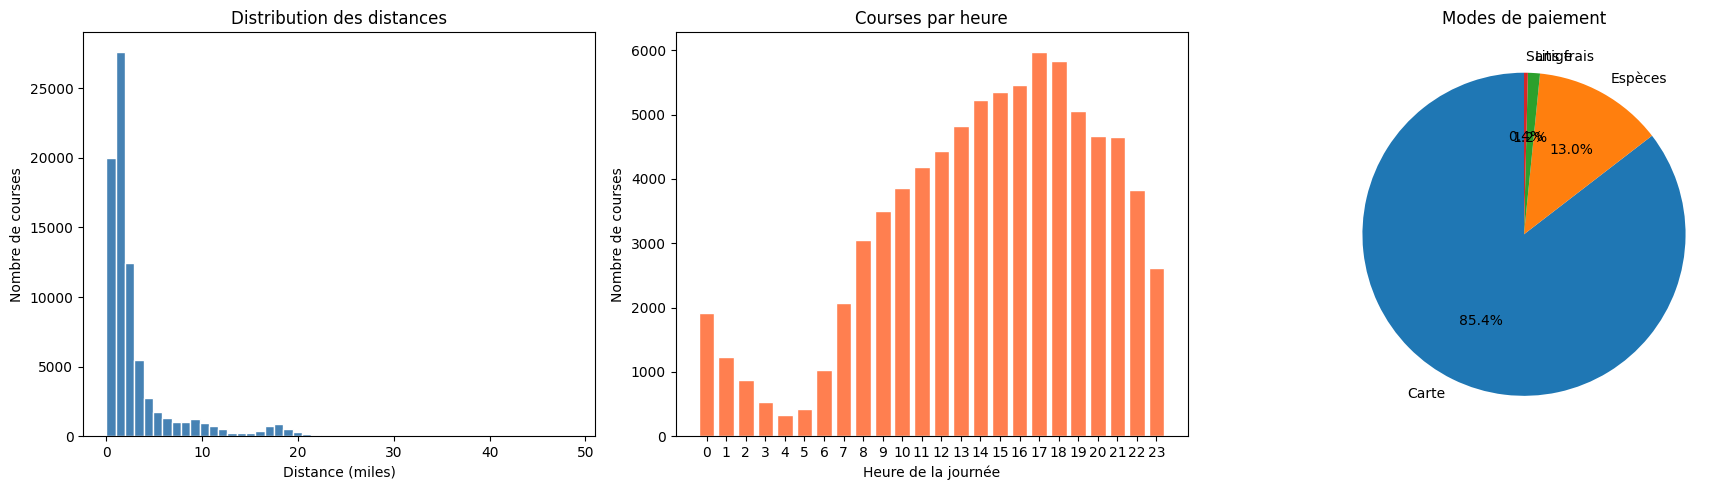

In [94]:
# Création des graphiques donnés en exemple dans l'énoncé, chacun dans un format adapté
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution des distances
axes[0].hist(df["trip_distance"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Distance (miles)")
axes[0].set_ylabel("Nombre de courses")
axes[0].set_title("Distribution des distances")

# 2. Nombre de courses par heure
courses_par_heure = df["tpep_pickup_datetime"].dt.hour.value_counts().sort_index()
axes[1].bar(courses_par_heure.index, courses_par_heure.values, color="coral", edgecolor="white")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Nombre de courses")
axes[1].set_title("Courses par heure")
axes[1].set_xticks(range(0, 24))

# 3. Répartition des modes de paiement
labels = {1: "Carte", 2: "Espèces", 3: "Sans frais", 4: "Litige"}
payment_counts = df["payment_type"].map(labels).value_counts()
axes[2].pie(payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%", startangle=90)
axes[2].set_title("Modes de paiement")

plt.tight_layout()
plt.show()

# **Etape 2 : Feature Engineering**

In [108]:
df["heure_journee"] = df["tpep_pickup_datetime"].dt.hour
df["jour_semaine"]  = df["tpep_pickup_datetime"].dt.dayofweek
df["est_weekend"] = df["jour_semaine"] >= 5
df["est_heure_pointe"] = df["heure_journee"].between(14,19)
df["vit_moyenne"] = df["trip_distance"]/(df["duree_course"]/60)
df["est_trajet_aeroport"] = df["RatecodeID"].isin([2,3])

# Vérification de la création des variables et de la cohérence de leurs valeurs
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,duree_course,prix_par_personne,heure_journee,jour_semaine,est_weekend,est_heure_pointe,vit_moyenne,est_trajet_aeroport
0,2,2025-01-11 11:43:46,2025-01-11 11:58:27,1.0,2.85,1.0,N,68,143,1,...,0.0,0.75,14.683333,16.3,11,5,True,False,11.645857,False
1,2,2025-01-29 19:15:17,2025-01-29 19:20:25,1.0,1.11,1.0,N,237,237,1,...,0.0,0.00,5.133333,7.9,19,2,False,True,12.974026,False
3,1,2025-01-22 08:57:53,2025-01-22 09:03:19,1.0,0.60,1.0,N,161,163,1,...,0.0,0.75,5.433333,7.2,8,2,False,False,6.625767,False
4,2,2025-01-18 12:26:34,2025-01-18 12:42:43,1.0,2.21,1.0,N,144,90,1,...,0.0,0.75,16.150000,15.6,12,5,True,False,8.210526,False
5,2,2025-01-14 22:00:24,2025-01-14 22:10:09,1.0,1.72,1.0,N,234,161,1,...,0.0,0.75,9.750000,12.1,22,1,False,False,10.584615,False


# **Etape 3 : Apprentissage supervisé**
# **Cas A**

**Régression linéaire**

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Les features dont je compte me servir (prix_par_personne serait de la triche pour les prédictions donc je ne la met pas)
features = ["trip_distance", "duree_course", "heure_journee", "jour_semaine", "est_weekend", "est_heure_pointe", "passenger_count"]

X=df[features]
y=df["fare_amount"] # je le préfère à total_amount pour garantir la précision, alors que total amount inclus aussi les pourboires et est donc plus compliqué à prévoir

# Ce passage est juste une application de la documentation et d'exemples en ligne
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5, test_size=0.2, train_size=0.8)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [97]:
# Ce passage aussi
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Evaluation de la régression Linéaire")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"R² : {r2_score(y_test, y_pred_lr):.4f}")

Evaluation de la régression Linéaire
RMSE : 4.70
MAE : 1.66
R² : 0.9157


Le R2 me parait être un bon résultat car le chiffre est suffisament éloigné de 1 pour ne pas me donner l'impression d'un overfitting, mais assez proche pour être satisfaisant.<br> D'après mes recherches, les 2 autres métriques symbolisent le taux d'erreur et doivent donc être le plus bas possible. Le MAE à 1.75 montre que quand mon modèle fait des erreurs elles sont généralement peu élevés, ce qui est encourageant. <br> Le RMSE est bas lui aussi, mais plus que le MAE. Il indique, si j'ai bien compris le calcul, que la moyenne des erreurs au carré (avant de faire la racine) est aux environ de 23 (4.8*4.8), ce qui signifie qu'il y a parfois de grosses erreurs pour avoir une moyenne aussi haut.

**Random Forest**

In [98]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=5, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Evaluation de la régression Linéaire")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_rf):.4f}")

Evaluation de la régression Linéaire
RMSE : 4.28
MAE  : 1.15
R²   : 0.9299


Les résultats sont plus encourageants que sur la simple régression linéaire. Les 3 métriques sont meilleurs sur ce modèle, mais le RMSE indique toujours la présence potentielle d'erreurs plus conséquentes que le MAE nous laisse penser.

Comparaison visuelle des résultats :

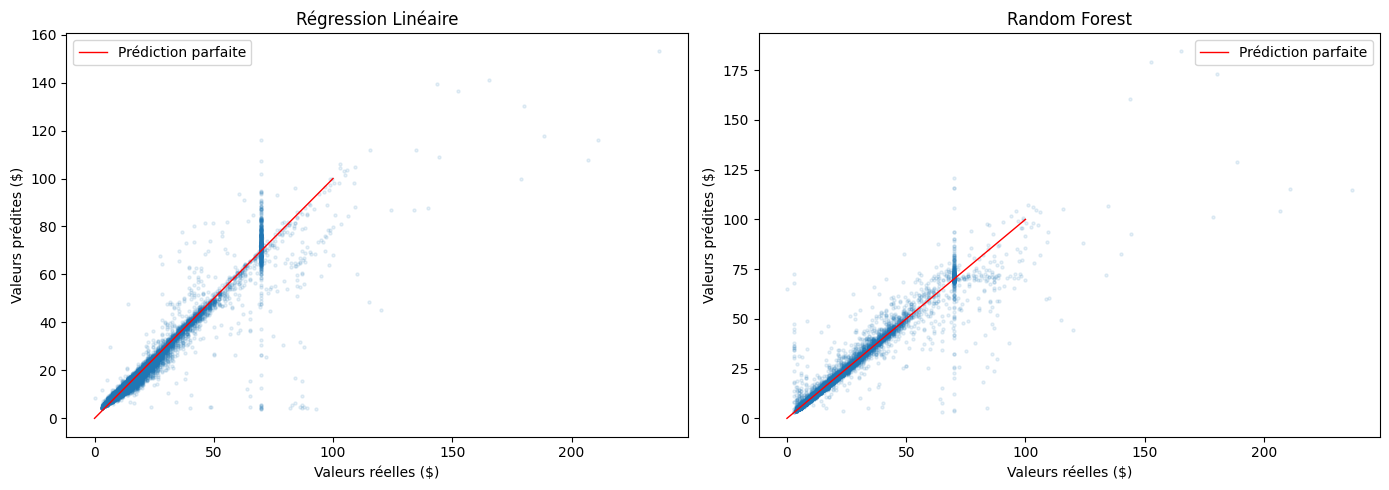

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(axes,[y_pred_lr, y_pred_rf],["Régression Linéaire", "Random Forest"]) :
    ax.scatter(y_test, y_pred, alpha=0.1, s=5)
    ax.plot([0, 100], [0, 100], color="red", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel("Valeurs réelles ($)")
    ax.set_ylabel("Valeurs prédites ($)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

# **Etape 4 : Apprentissage non-supervisé**
# **Cas A**

**Selection des features et standardisation**

In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Les features demandés
features_cluster = ["trip_distance","duree_course","heure_journee", "total_amount"]
X_cluster = df[features_cluster].copy()

# Standardisation des données comme demandé
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

**Tracé du coude**

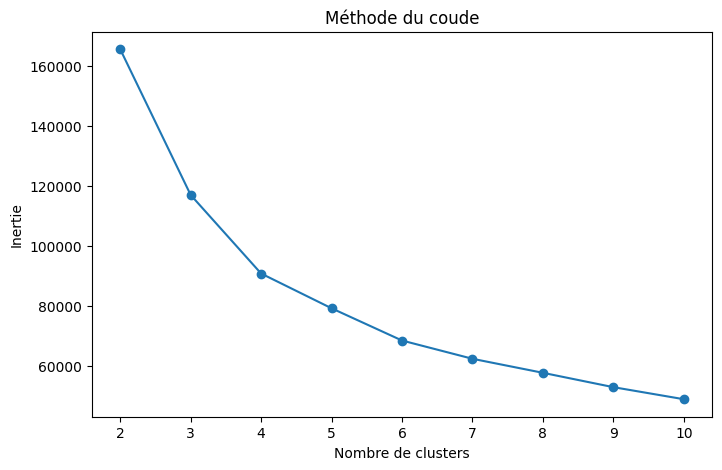

In [110]:
# Méthode du coude, tracé de graphique, et identification du nombre de clusters le plus pertinent (4 selon moi dans ce cas)

inerties = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=5, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inerties, marker="o")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()

**K-Means et affichage des profils**

In [111]:
km = KMeans(n_clusters=4, random_state=5, n_init=10)
X_cluster["cluster"] = km.fit_predict(X_scaled)

profil = X_cluster.groupby("cluster").mean().round(2)
print(profil)

# J'ai l'impression qu'au cours de plusieurs exécutions, l'ordre des clusters peut changer malgré le random_state set. Je me servirais donc du trip distance comme identifiant de cluster dans mon analyse

         trip_distance  duree_course  heure_journee  total_amount
cluster                                                          
0                 6.38         26.25          14.82         46.16
1                17.18         45.94          14.32         91.88
2                 1.56         10.23          18.12         19.70
3                 1.62         10.28           8.70         18.74


**Analyse des résultats**

Nous pouvons voir au 1er coup d'oeil que 2 de ces clusters représente des navetteurs, les clusters dont les trip distance sont 1.56 et 1.62 . Les moyennes indique que les trajets ont lieu un peu avant 9h et un peu après 18h, des horaires de travails classiques, et les distances assez faibles sont symbole de personne pressés, où en tout cas pas de personnes qui veulent voyager (1km semble pas pour cela). Il reste ensuite à identifier les profils des 2 clusters restants

In [103]:
# Objectif : identifier les destinations fréquentes des 2 clusters restants à l'aide du DOLocationID et du csv décrivant les zones de taxi de NYC
# Lookup table récupéré sur le site officiel de nyc : https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
df.loc[X_cluster[X_cluster["cluster"] == 0].index, "DOLocationID"].value_counts()

,count
DOLocationID,
138,564
236,399
230,320
231,301
161,277
...,...
27,1
81,1
153,1


In [104]:
df.loc[X_cluster[X_cluster["cluster"] == 3].index, "DOLocationID"].value_counts()

,count
DOLocationID,
161,1576
237,1572
236,1525
162,954
163,897
...,...
198,1
175,1
98,1


En analysant les destinations des 2 clusters restant, il me semble qu'ils représentent des touristes. La moyenne des horaires n'évoque pas des personnes en période de travail, mais je voulais quand même analyser les destinations pour être sur.
Le cluster de 17 km à comme destination la plus prisée le JFK Airport (id=132) tandis que le dernier cluster a le LaGuardia Airport (id=138). Ces 2 clusters ont aussi comme destination commune l'id 230, qui représente TimeSquare, renforçant cette hypothèse